In [1]:
import pandas as pd

df = pd.read_csv("Cleaned_Bank_Data.csv")

df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             41176 non-null  int64  
 1   job                             41176 non-null  str    
 2   marital                         41176 non-null  str    
 3   education                       41176 non-null  str    
 4   default                         41176 non-null  str    
 5   housing                         41176 non-null  str    
 6   loan                            41176 non-null  str    
 7   contact                         41176 non-null  str    
 8   month                           41176 non-null  str    
 9   day_of_week                     41176 non-null  str    
 10  duration                        41176 non-null  int64  
 11  campaign                        41176 non-null  int64  
 12  pdays                           41176 non-n

In [2]:
# What is the overall subscription rate, and how imbalanced is the campaign outcome?
outcome_counts=df['subscribed'].value_counts()
outcome_percentages=df['subscribed'].value_counts(normalize=True)*100

print("Number of subscriptions (yes/no):")
print(outcome_counts)

print("\nPercentage distribution:")
print(outcome_percentages)

Number of subscriptions (yes/no):
subscribed
no     36537
yes     4639
Name: count, dtype: int64

Percentage distribution:
subscribed
no     88.733728
yes    11.266272
Name: proportion, dtype: float64


In [3]:
'''Customer Age Distribution: What does the age distribution of contacted customers 
look like, and what age ranges dominate the campaign?'''

mean_age=df['age'].mean()
median_age=df['age'].median()
min_age=df['age'].min()
max_age=df['age'].max()
std_age=df['age'].std()

# Quartiles Upper, Lower
q1=df['age'].quantile(0.25)
q3=df['age'].quantile(0.75)

print("Mean age:",round(mean_age, 2))
print("Median age:",median_age)
print("Minimum age:",min_age)
print("Maximum age:",max_age)
print("Standard deviation:",round(std_age, 2))
print("Q1 (25th percentile):",q1)
print("Q3 (75th percentile):",q3)


Mean age: 40.02
Median age: 38.0
Minimum age: 17
Maximum age: 98
Standard deviation: 10.42
Q1 (25th percentile): 32.0
Q3 (75th percentile): 47.0


In [4]:
'''Age and Subscription Relationship: How does subscription conversion vary across customer age groups, 
and which age groups show the highest observed conversion?'''

age_conversion=(df.groupby('age_group').agg(total_contacts=('subscribed','count'),
successful_subscriptions=('subscribed', lambda x:(x == 'yes').sum()),
unsuccessful_contacts=('subscribed', lambda x:(x == 'no').sum())))

age_conversion['conversion_rate']=(age_conversion['successful_subscriptions'] / age_conversion['total_contacts'] * 100
).round(2)

age_conversion=age_conversion.sort_values(by='conversion_rate',ascending=False).reset_index()
print(age_conversion)

  age_group  total_contacts  successful_subscriptions  unsuccessful_contacts  \
0        65             662                       313                    349   
1  Under 25            1067                       256                    811   
2     55-64            3566                       484                   3082   
3     25-34           13684                      1666                  12018   
4     35-44           13495                      1168                  12327   
5     45-54            8702                       752                   7950   

   conversion_rate  
0            47.28  
1            23.99  
2            13.57  
3            12.17  
4             8.66  
5             8.64  


In [5]:
'''Previous Contact Effect:How strongly is previous campaign contact
associated with subscription conversion?'''

prev_contact=df.groupby('previously_contacted').agg( total_contacts=('subscribed','count'),
successful_subscriptions=('subscribed', lambda x:(x == 'yes').sum()),
unsuccessful_contacts=('subscribed', lambda x:(x == 'no').sum()))

prev_contact['conversion_rate']=(prev_contact['successful_subscriptions']/prev_contact['total_contacts']* 100
).round(2)

# Extract conversion rates
yes_rate = prev_contact.loc['Yes', 'conversion_rate']
no_rate  = prev_contact.loc['No', 'conversion_rate']

conversion_rate_difference =round(yes_rate -no_rate, 2)
conversion_rate_ratio =round(yes_rate/ no_rate, 2)

prev_contact['conversion_rate_difference'] =conversion_rate_difference
prev_contact['conversion_rate_ratio'] =conversion_rate_ratio

print(prev_contact.reset_index())

  previously_contacted  total_contacts  successful_subscriptions  \
0                   No           39661                      3672   
1                  Yes            1515                       967   

   unsuccessful_contacts  conversion_rate  conversion_rate_difference  \
0                  35989             9.26                       54.57   
1                    548            63.83                       54.57   

   conversion_rate_ratio  
0                   6.89  
1                   6.89  


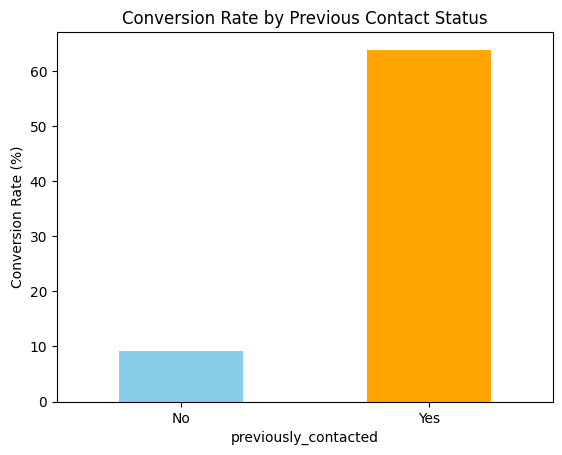

In [6]:
import matplotlib.pyplot as plt

# Bar chart of conversion rates
prev_contact['conversion_rate'].plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Conversion Rate by Previous Contact Status")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()


## Chi-square statistic

In [7]:
'''descriptive analysis → statistical inference.Is the relationship between previous campaign contact and subscription statistically significant,
or could the observed difference reasonably be due to random variation?'''

from scipy.stats import chi2_contingency

#contingency table
contingency = pd.crosstab(df['previously_contacted'], df['subscribed'])

print("Contingency Table:\n", contingency)

# Run Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-square statistic:",chi2)
print("p-value:",p)
print("Degrees of freedom:",dof)
print("Expected frequencies:\n",expected)


Contingency Table:
 subscribed               no   yes
previously_contacted             
No                    35989  3672
Yes                     548   967

Chi-square statistic: 4341.344316869189
p-value: 0.0
Degrees of freedom: 1
Expected frequencies:
 [[35192.68401496  4468.31598504]
 [ 1344.31598504   170.68401496]]


In [8]:
# Is customer age group statistically associated with subscription outcome?

contingency = pd.crosstab(df['age_group'], df['subscribed'])
print("Contingency Table:\n", contingency)


chi2,p,dof,expected =chi2_contingency(contingency)

print("\nChi-square statistic:",chi2)
print("p-value:",p)
print("Degrees of freedom:",dof)
print("Expected frequencies:\n",expected)

Contingency Table:
 subscribed     no   yes
age_group              
25-34       12018  1666
35-44       12327  1168
45-54        7950   752
55-64        3082   484
65            349   313
Under 25      811   256

Chi-square statistic: 1214.0485667186913
p-value: 2.660412520830593e-260
Degrees of freedom: 5
Expected frequencies:
 [[12142.32339227  1541.67660773]
 [11974.61664562  1520.38335438]
 [ 7721.6090441    980.3909559 ]
 [ 3164.24475423   401.75524577]
 [  587.41728191    74.58271809]
 [  946.78888187   120.21111813]]


In [9]:
'''Is the number of contacts made during the current campaign (campaign_contact_group)
statistically associated with subscription outcome?'''

contingency = pd.crosstab(df['campaign_contact_group'], df['subscribed'])
print("Contingency Table:\n", contingency)


chi2,p,dof,expected =chi2_contingency(contingency)

print("\nChi-square statistic:",chi2)
print("p-value:",p)
print("Degrees of freedom:",dof)
print("Expected frequencies:\n",expected)

Contingency Table:
 subscribed                 no   yes
campaign_contact_group             
1 Contact               15335  2299
11+ Contacts              842    27
2 Contacts               9357  1211
3-5 Contacts             8646   943
6-10 Contacts            2357   159

Chi-square statistic: 194.84711915332002
p-value: 4.814871888219752e-41
Degrees of freedom: 4
Expected frequencies:
 [[15647.30566349  1986.69433651]
 [  771.09609967    97.90390033]
 [ 9377.38041578  1190.61958422]
 [ 8508.67721488  1080.32278512]
 [ 2232.54060618   283.45939382]]


In [10]:
# Is the contact method (contact) statistically associated with subscription outcome?

contingency = pd.crosstab(df['contact'], df['subscribed'])
print("Contingency Table:\n", contingency)


chi2,p,dof,expected =chi2_contingency(contingency)

print("\nChi-square statistic:",chi2)
print("p-value:",p)
print("Degrees of freedom:",dof)
print("Expected frequencies:\n",expected)


Contingency Table:
 subscribed     no   yes
contact                
cellular    22283  3852
telephone   14254   787

Chi-square statistic: 862.0807365848323
p-value: 1.7187406241263767e-189
Degrees of freedom: 1
Expected frequencies:
 [[23190.55991354  2944.44008646]
 [13346.44008646  1694.55991354]]


In [11]:
Is education level statistically associated with subscription outcome?

contingency = pd.crosstab(df['education'], df['subscribed'])
print("Contingency Table:\n", contingency)


chi2,p,dof,expected =chi2_contingency(contingency)

print("\nChi-square statistic:",chi2)
print("p-value:",p)
print("Degrees of freedom:",dof)
print("Expected frequencies:\n",expected)

Object `outcome` not found.
Contingency Table:
 subscribed              no   yes
education                       
basic.4y              3748   428
basic.6y              2103   188
basic.9y              5572   473
high.school           8481  1031
illiterate              14     4
professional.course   4645   595
university.degree    10495  1669
unknown               1479   251

Chi-square statistic: 192.8485047401879
p-value: 3.746768377534744e-38
Degrees of freedom: 7
Expected frequencies:
 [[3.70552050e+03 4.70479503e+02]
 [2.03288972e+03 2.58110283e+02]
 [5.36395388e+03 6.81046119e+02]
 [8.44035224e+03 1.07164776e+03]
 [1.59720711e+01 2.02792889e+00]
 [4.64964737e+03 5.90352633e+02]
 [1.07935707e+04 1.37042928e+03]
 [1.53509350e+03 1.94906499e+02]]


In [12]:
# question Is job type statistically associated with subscription outcome?

contingency = pd.crosstab(df['job'], df['subscribed'])
print("Contingency Table:\n", contingency)


chi2,p,dof,expected =chi2_contingency(contingency)

print("\nChi-square statistic:",chi2)
print("p-value:",p)
print("Degrees of freedom:",dof)
print("Expected frequencies:\n",expected)

Contingency Table:
 subscribed       no   yes
job                      
admin.         9068  1351
blue-collar    8615   638
entrepreneur   1332   124
housemaid       954   106
management     2596   328
retired        1284   434
self-employed  1272   149
services       3644   323
student         600   275
technician     6009   730
unemployed      870   144
unknown         293    37

Chi-square statistic: 961.7438037353177
p-value: 3.2684116066165443e-199
Degrees of freedom: 11
Expected frequencies:
 [[9245.16716048 1173.83283952]
 [8210.53188751 1042.46811249]
 [1291.96308529  164.03691471]
 [ 940.57752089  119.42247911]
 [2594.57421799  329.42578201]
 [1524.44545366  193.55454634]
 [1260.90628036  160.09371964]
 [3520.06700505  446.93299495]
 [ 776.42012337   98.57987663]
 [5979.7659559   759.2340441 ]
 [ 899.76000583  114.23999417]
 [ 292.82130367   37.17869633]]


## Effect Size

In [13]:
'''question - now we'll measure association strength using Cramér's V.= How strong is the association 
between previous campaign contact and subscription outcome?'''

import numpy as np

# relationship between previously_contacted and subscribed using your existing chi‑square result:

chi2=4341.34   
n=41176        
r,c=2, 2      

# Calculate Cramér's V
cramers_v=np.sqrt(chi2 / (n * min(r-1,c-1)))
print("Cramer's V:",round(cramers_v,3))


Cramer's V: 0.325


In [14]:
#question- How strong is the association between contact method and subscription outcome?
# contact ↔ subscribed

chi2=862.08   # chi squre value we calculated previously 
n=41176        #our total size
r,c=2,2     #table has 2 rows (contact methods: cellular, telephone) and 2 columns (subscription outcomes: yes, no).

# Calculate Cramér's V
cramers_v= np.sqrt(chi2 / (n * min(r-1,c-1)))
print("Cramer's V:",round(cramers_v,3))

Cramer's V: 0.145


In [15]:
# question- How strong is the association between age group and subscription outcome?
# age_group ↔ subscribed

chi2=1214.05   
n=41176        
r,c=6,2      

# Calculate Cramér's V
cramers_v=np.sqrt(chi2 / (n * min(r-1,c-1)))
print("Cramer's V:",round(cramers_v,3))

Cramer's V: 0.172


## Call Duration ↔ Subscribed

In [16]:
# Is call duration associated with subscription outcome?

summary=df.groupby('subscribed')['duration'].describe()

q1=df.groupby('subscribed')['duration'].quantile(0.25)
q3=df.groupby('subscribed')['duration'].quantile(0.75)

comparison = summary[['mean','50%','std','min','max']].rename(columns={'50%':'median'})
comparison['Q1']=q1
comparison['Q3']=q3

print(comparison.round(2))

              mean  median     std   min     max     Q1     Q3
subscribed                                                    
no          220.87   164.0  207.12   0.0  4918.0   95.0  279.0
yes         553.26   449.0  401.19  37.0  4199.0  253.5  741.5


In [17]:
# question- Is the difference in call duration between subscribed and non-subscribed records statistically significant?

# two-sample t-test.

from scipy.stats import ttest_ind

yes_duration=df[df['subscribed'] =='yes']['duration']
no_duration=df[df['subscribed'] =='no']['duration']

t_stat,p_val=ttest_ind(yes_duration,no_duration,equal_var=False)

print("t-statistic:",round(t_stat, 3))
print("p-value:",p_val)

t-statistic: 55.498
p-value: 0.0


## campaign ↔ subscribed

In [18]:
# Is the number of contacts made during the current campaign associated with subscription outcome?

summary=df.groupby('subscribed')['campaign'].describe()
q1=df.groupby('subscribed')['campaign'].quantile(0.25)
q3=df.groupby('subscribed')['campaign'].quantile(0.75)

comparison=summary[['mean','50%','std','min','max']].rename(columns={'50%':'median'})
comparison['Q1']=q1
comparison['Q3']=q3

print(comparison.round(2))

            mean  median   std  min   max   Q1   Q3
subscribed                                         
no          2.63     2.0  2.87  1.0  56.0  1.0  3.0
yes         2.05     2.0  1.67  1.0  23.0  1.0  2.0


In [19]:
# Is the number of campaign contacts significantly different between subscribed and non-subscribed records?

yes_campaign=df[df['subscribed'] =='yes']['campaign']
no_campaign=df[df['subscribed'] =='no']['campaign']

t_stat, p_val = ttest_ind(yes_campaign,no_campaign,equal_var=False)

print("t-statistic:",round(t_stat, 3))
print("p-value:",p_val)

t-statistic: -20.248
p-value: 4.219168316468661e-89


In [20]:
# Effect Size
# How large is the difference in campaign-contact frequency between subscribed and non-subscribed records?
yes_campaign=df[df['subscribed'] =='yes']['campaign']
no_campaign =df[df['subscribed']== 'no']['campaign']

mean_yes= yes_campaign.mean()
mean_no =no_campaign.mean()
std_yes =yes_campaign.std()
std_no =no_campaign.std()
n_yes =yes_campaign.shape[0]
n_no =no_campaign.shape[0]

pooled_std = np.sqrt(((n_yes - 1)*std_yes**2 +(n_no - 1)*std_no**2) / (n_yes + n_no - 2))

# Cohen's d
cohens_d=(mean_yes-mean_no)/pooled_std

print("Mean (yes):",round(mean_yes, 2))
print("Mean (no):",round(mean_no, 2))
print("Std (yes):",round(std_yes, 2))
print("Std (no):",round(std_no, 2))
print("Pooled Std:",round(pooled_std, 2))
print("Cohen's d:",round(cohens_d, 3))

Mean (yes): 2.05
Mean (no): 2.63
Std (yes): 1.67
Std (no): 2.87
Pooled Std: 2.76
Cohen's d: -0.21


## Correlation Analysis

In [21]:
# question- How are the key numeric campaign and economic variables correlated with each other?

columns = ['age','duration','campaign','previous','emp_var_rate','cons_price_idx','cons_conf_idx','euribor3m','nr_employed']

# correlation matrix
corr_matrix = df[columns].corr()

print(corr_matrix.round(3))

                  age  duration  campaign  previous  emp_var_rate  \
age             1.000    -0.001     0.005     0.024        -0.000   
duration       -0.001     1.000    -0.072     0.021        -0.028   
campaign        0.005    -0.072     1.000    -0.079         0.151   
previous        0.024     0.021    -0.079     1.000        -0.421   
emp_var_rate   -0.000    -0.028     0.151    -0.421         1.000   
cons_price_idx  0.001     0.005     0.128    -0.203         0.775   
cons_conf_idx   0.129    -0.008    -0.014    -0.051         0.196   
euribor3m       0.011    -0.033     0.135    -0.455         0.972   
nr_employed    -0.017    -0.045     0.144    -0.501         0.907   

                cons_price_idx  cons_conf_idx  euribor3m  nr_employed  
age                      0.001          0.129      0.011       -0.017  
duration                 0.005         -0.008     -0.033       -0.045  
campaign                 0.128         -0.014      0.135        0.144  
previous             

In [22]:
# question- How do the key numeric variables differ between subscribed and non-subscribed records?

columns = ['age','duration','campaign','previous','emp_var_rate','cons_price_idx','cons_conf_idx','euribor3m','nr_employed']
means = df.groupby('subscribed')[columns].mean()

comparison = pd.DataFrame({
    'variable': columns,
    'mean_no': means.loc['no'].values,
    'mean_yes': means.loc['yes'].values,
    'difference (yes - no)': means.loc['yes'].values - means.loc['no'].values
})

print(comparison.round(3))

         variable   mean_no  mean_yes  difference (yes - no)
0             age    39.911    40.912                  1.001
1        duration   220.868   553.256                332.388
2        campaign     2.633     2.052                 -0.581
3        previous     0.132     0.493                  0.360
4    emp_var_rate     0.249    -1.233                 -1.482
5  cons_price_idx    93.604    93.355                 -0.249
6   cons_conf_idx   -40.593   -39.791                  0.802
7       euribor3m     3.811     2.123                 -1.688
8     nr_employed  5176.136  5095.205                -80.931


## Economic Conditions & Subscription

In [27]:

econ_vars = ['emp_var_rate','euribor3m','nr_employed','cons_price_idx']

comparison = df.groupby('subscribed')[econ_vars].agg({
    'emp_var_rate': ['mean','median','std','min','max',
                     lambda x: x.quantile(0.25),
                     lambda x: x.quantile(0.75)],
    'euribor3m': ['mean','median','std','min','max',
                  lambda x: x.quantile(0.25),
                  lambda x: x.quantile(0.75)],
    'nr_employed': ['mean','median','std','min','max',
                    lambda x: x.quantile(0.25),
                    lambda x: x.quantile(0.75)],
    'cons_price_idx': ['mean','median','std','min','max',
                       lambda x: x.quantile(0.25),
                       lambda x: x.quantile(0.75)]
})

# Rename the quantile columns for clarity
comparison = comparison.rename(columns={
    '<lambda_0>':'Q1',
    '<lambda_1>':'Q3'
})

print(comparison.round(3))



           emp_var_rate                                   euribor3m         \
                   mean median    std  min  max   Q1   Q3      mean median   
subscribed                                                                   
no                0.249    1.1  1.483 -3.4  1.4 -1.8  1.4     3.811  4.857   
yes              -1.233   -1.8  1.624 -3.4  1.4 -1.8 -0.1     2.123  1.266   

                   ... nr_employed                 cons_price_idx          \
              std  ...         max      Q1      Q3           mean  median   
subscribed         ...                                                      
no          1.638  ...        5228  5099.0  5228.0         93.604  93.918   
yes         1.743  ...        5228  5018.0  5191.0         93.355  93.200   

                                                   
              std     min     max      Q1      Q3  
subscribed                                         
no          0.559  92.201  94.767  93.075  93.994  
yes         0.6

## Economic Variable Statistical Test

In [28]:
# Question - Is emp_var_rate statistically different between subscribed and non-subscribed records?

yes_emp=df[df['subscribed'] =='yes']['emp_var_rate']
no_emp=df[df['subscribed'] =='no']['emp_var_rate']

t_stat,p_val=ttest_ind(yes_emp, no_emp, equal_var=False)

print("t-statistic:", round(t_stat,3))
print("p-value:",p_val)

t-statistic: -59.117
p-value: 0.0


## Economic Variable Statistical Test #2

In [29]:
# Question - Is euribor3m statistically different between subscribed and non-subscribed records?

yes_emp=df[df['subscribed'] =='yes']['euribor3m']
no_emp=df[df['subscribed'] =='no']['euribor3m']

t_stat,p_val=ttest_ind(yes_emp, no_emp, equal_var=False)

print("t-statistic:", round(t_stat,3))
print("p-value:",p_val)

t-statistic: -62.56
p-value: 0.0


## Economic Variable Statistical Test #3

In [30]:
# Is nr_employed statistically different between subscribed and non-subscribed records?

yes_emp=df[df['subscribed'] =='yes']['nr_employed']
no_emp=df[df['subscribed'] =='no']['nr_employed']

t_stat,p_val=ttest_ind(yes_emp, no_emp, equal_var=False)

print("t-statistic:", round(t_stat,3))
print("p-value:",p_val)

t-statistic: -60.984
p-value: 0.0


## Economic Variable Statistical Test #4

In [31]:
# Question - Is cons_price_idx statistically different between subscribed and non-subscribed records?

yes_emp=df[df['subscribed'] =='yes']['cons_price_idx']
no_emp=df[df['subscribed'] =='no']['cons_price_idx']

t_stat,p_val=ttest_ind(yes_emp, no_emp, equal_var=False)

print("t-statistic:", round(t_stat,3))
print("p-value:",p_val)

t-statistic: -24.067
p-value: 9.7235258603126e-122


## Economic Environment Summary

In [32]:
# Question - How do the key economic variables differ between subscribed and non-subscribed records?

econ_vars = ['emp_var_rate','euribor3m','nr_employed','cons_price_idx']
means = df.groupby('subscribed')[econ_vars].mean()

comparison = pd.DataFrame({'variable': econ_vars,'mean_no': means.loc['no'].values,'mean_yes': means.loc['yes'].values,
'difference (yes - no)': means.loc['yes'].values - means.loc['no'].values
})

print(comparison.round(3))

         variable   mean_no  mean_yes  difference (yes - no)
0    emp_var_rate     0.249    -1.233                 -1.482
1       euribor3m     3.811     2.123                 -1.688
2     nr_employed  5176.136  5095.205                -80.931
3  cons_price_idx    93.604    93.355                 -0.249


In [42]:
# Question - How does conversion change as the number of campaign contacts increases, and where does repeated contact show diminishing conversion?


conversion = (df.groupby('campaign_contact_group').agg(
total_contacts=('subscribed','count'), successful_subscriptions=('subscribed', lambda x: (x=='yes').sum())).reset_index())

conversion['conversion_rate']=(conversion['successful_subscriptions']/conversion['total_contacts'] *100).round(2)

conversion = conversion.sort_values('campaign_contact_group')

print(conversion)

  campaign_contact_group  total_contacts  successful_subscriptions  \
0              1 Contact           17634                      2299   
1           11+ Contacts             869                        27   
2             2 Contacts           10568                      1211   
3           3-5 Contacts            9589                       943   
4          6-10 Contacts            2516                       159   

   conversion_rate  
0            13.04  
1             3.11  
2            11.46  
3             9.83  
4             6.32  


## Outlier Analysis

In [45]:
# Duration Outliers

q1 =df['duration'].quantile(0.25)
q3 =df['duration'].quantile(0.75)

iqr=q3 - q1


lower_bound =q1 - 1.5 * iqr
upper_bound =q3 + 1.5 * iqr

below =(df['duration']< lower_bound).sum()
above =(df['duration']> upper_bound).sum()

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Outliers below:", below)
print("Outliers above:", above)

Q1: 102.0
Q3: 319.0
IQR: 217.0
Lower bound: -223.5
Upper bound: 644.5
Outliers below: 0
Outliers above: 2963


## Campaign Contact Outliers

In [46]:
q1 =df['campaign'].quantile(0.25)
q3 =df['campaign'].quantile(0.75)

iqr=q3 - q1


lower_bound =q1 - 1.5 * iqr
upper_bound =q3 + 1.5 * iqr

below =(df['campaign']< lower_bound).sum()
above =(df['campaign']> upper_bound).sum()

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Outliers below:", below)
print("Outliers above:", above)

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower bound: -2.0
Upper bound: 6.0
Outliers below: 0
Outliers above: 2406


## Previous Contact Frequency Outliers

In [47]:
q1 =df['previous'].quantile(0.25)
q3 =df['previous'].quantile(0.75)

iqr=q3 - q1


lower_bound =q1 - 1.5 * iqr
upper_bound =q3 + 1.5 * iqr

below=(df['previous']< lower_bound).sum()
above=(df['previous']> upper_bound).sum()

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Outliers below:", below)
print("Outliers above:", above)

Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower bound: 0.0
Upper bound: 0.0
Outliers below: 0
Outliers above: 5625


## Business-Focused Visualization

### Subscription Conversion by Campaign Contact Frequency

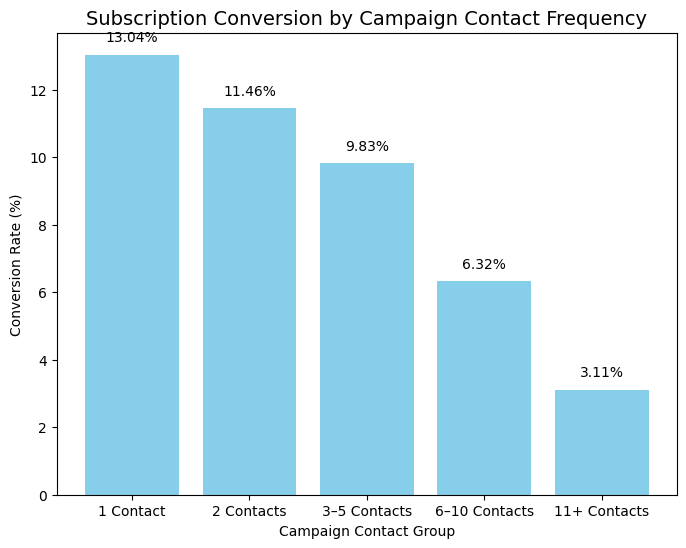

In [48]:
import matplotlib.pyplot as plt

# Data
groups = ['1 Contact','2 Contacts','3–5 Contacts','6–10 Contacts','11+ Contacts']
conversion_rates = [13.04, 11.46, 9.83, 6.32, 3.11]


plt.figure(figsize=(8,6))
bars=plt.bar(groups, conversion_rates, color='skyblue')

for bar, rate in zip(bars, conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{rate}%",ha='center',va='bottom', fontsize=10)

# Title and axis labels
plt.title("Subscription Conversion by Campaign Contact Frequency", fontsize=14)
plt.xlabel("Campaign Contact Group")
plt.ylabel("Conversion Rate (%)")

plt.show()


### Conversion by Age Group

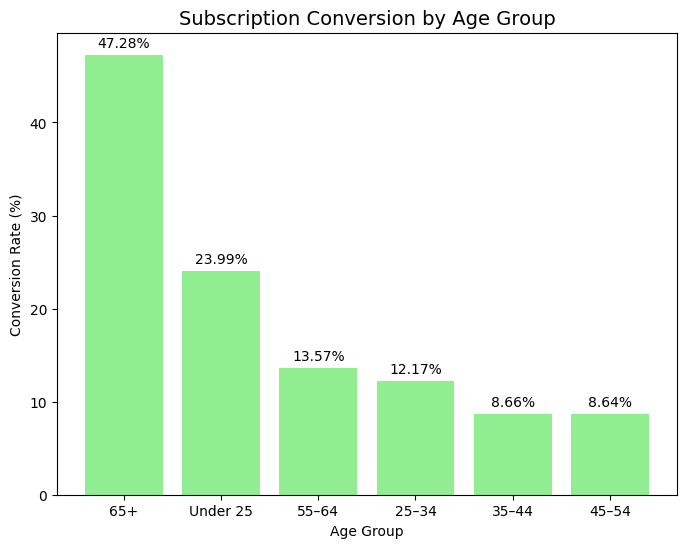

In [50]:

age_groups = ['65+','Under 25','55–64','25–34','35–44','45–54']
conversion_rates = [47.28, 23.99, 13.57, 12.17, 8.66, 8.64]


plt.figure(figsize=(8,6))
bars = plt.bar(age_groups, conversion_rates, color='lightgreen')

# Add labels on bars
for bar, rate in zip(bars, conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{rate}%",ha='center',va='bottom',fontsize=10)


plt.title("Subscription Conversion by Age Group", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")

plt.show()


### Conversion by Contact Method

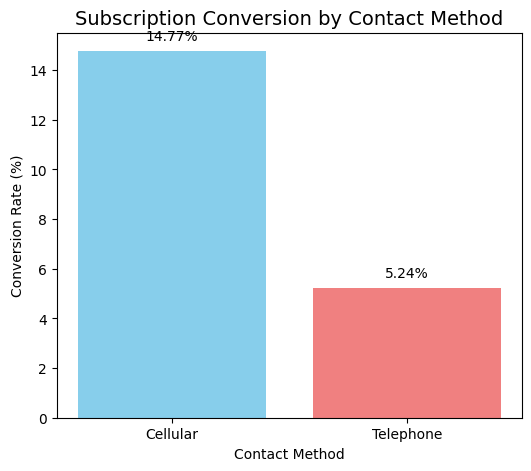

In [56]:

contacts =['Cellular','Telephone']
conversion_rates =[14.77, 5.24]

plt.figure(figsize=(6,5))
bars = plt.bar(contacts, conversion_rates, color=['skyblue','lightcoral'])

for bar, rate in zip(bars, conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{rate}%", ha='center', va='bottom', fontsize=10)

plt.title("Subscription Conversion by Contact Method", fontsize=14)
plt.xlabel("Contact Method")
plt.ylabel("Conversion Rate (%)")

plt.show()


### Subscription Conversion by Previous Campaign Outcome

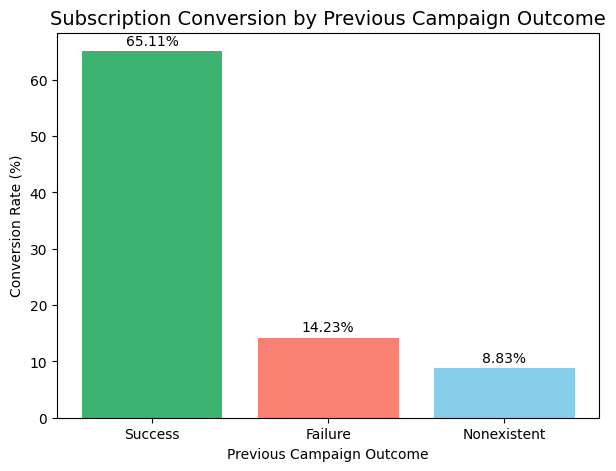

In [57]:

outcomes = ['Success','Failure','Nonexistent']
conversion_rates = [65.11,14.23,8.83]

plt.figure(figsize=(7,5))
bars = plt.bar(outcomes, conversion_rates, color=['mediumseagreen','salmon','skyblue'])

for bar, rate in zip(bars, conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{rate}%", ha='center', va='bottom', fontsize=10)

plt.title("Subscription Conversion by Previous Campaign Outcome", fontsize=14)
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Conversion Rate (%)")

plt.show()


### Subscription Conversion by Employment Level

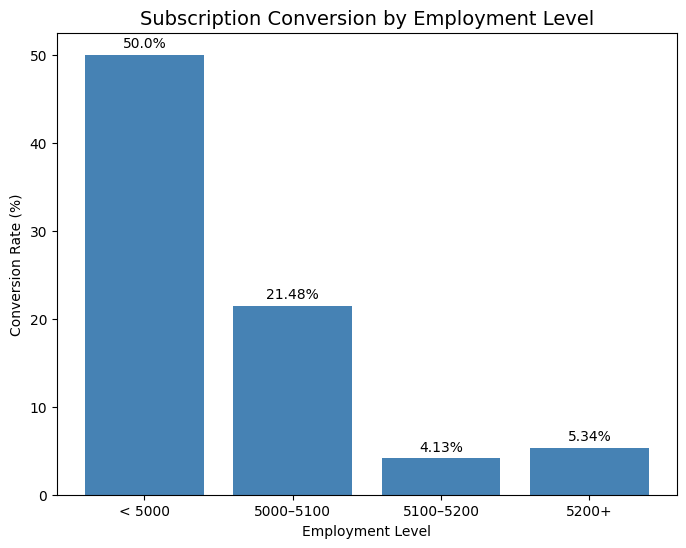

In [58]:

employment_bands = ['< 5000','5000–5100','5100–5200','5200+']
conversion_rates = [50.00,21.48,4.13,5.34]

plt.figure(figsize=(8,6))
bars = plt.bar(employment_bands, conversion_rates, color='steelblue')

for bar, rate in zip(bars, conversion_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{rate}%", ha='center',va='bottom',fontsize=10)

plt.title("Subscription Conversion by Employment Level", fontsize=14)
plt.xlabel("Employment Level")
plt.ylabel("Conversion Rate (%)")

plt.show()


# Consolidated Business Insights

In [60]:
final_insights = [
    "Finding → Overall conversion rate was 11.27%, with 4,639 successful subscriptions and 36,537 non-subscriptions. Evidence → Most campaign records resulted in no subscription. Business implication → The overall campaign had substantial room for improvement through more targeted customer segmentation and outreach strategies.",
    
    "Finding → Previously contacted records had a 63.83% conversion rate compared with 9.26% for first-time contacts, a difference of 54.57 percentage points. Evidence → Cramér's V = 0.325 and the chi-square test showed a statistically significant association. Business implication → Previous campaign history is strongly relevant to observed subscription outcomes, highlighting the potential value of prioritizing customers with prior engagement.",
    
    "Finding → Conversion declined as the number of current-campaign contacts increased: 13.04% for 1 contact, 11.46% for 2, 9.83% for 3–5, 6.32% for 6–10, and 3.11% for 11+ contacts. Evidence → Cohen's d = −0.21 indicates a small negative effect in campaign-contact frequency between subscribed and non-subscribed records. Business implication → The analysis shows diminishing observed conversion with repeated contact, suggesting that excessive outreach should be reviewed carefully.",
    
    "Finding → Conversion varied substantially across age groups, with 65+ at 47.28%, Under 25 at 23.99%, 55–64 at 13.57%, 25–34 at 12.17%, 35–44 at 8.66%, and 45–54 at 8.64%. Evidence → Cramér's V = 0.172 indicates an association between age group and subscription outcome; education and job type also showed statistically significant associations. Business implication → Customer characteristics can support more differentiated campaign segmentation and messaging.",
    
    "Finding → Conversion varied by contact method: Cellular = 14.77% compared with Telephone = 5.24%. Evidence → Cramér's V = 0.145 and the chi-square test showed a statistically significant association. Business implication → The observed results indicate that contact method should be considered when evaluating campaign performance.",
    
    "Finding → Previous campaign outcome was strongly associated with current subscription conversion: Success = 65.11%, Failure = 14.23%, and Nonexistent = 8.83%. Evidence → Conversion rates differed substantially across previous campaign outcome categories. Business implication → Previous campaign outcomes can be used as an important segmentation variable when evaluating customer engagement and campaign opportunities.",
    
    "Finding → Economic variables differed between subscribed and non-subscribed records. Evidence → Subscribed records had lower mean employment variation rate (-1.233 vs 0.249), lower Euribor 3-month rate (2.123 vs 3.811), lower number employed (5095.205 vs 5176.136), and slightly lower consumer price index (93.355 vs 93.604). Statistical tests showed extremely small p-values. Business implication → Subscription outcomes were associated with the prevailing economic environment, indicating that campaign performance should be interpreted in its broader economic context."
]

for i, insight in enumerate(final_insights, 1):
    print(f"{i}. {insight}")

1. Finding → Overall conversion rate was 11.27%, with 4,639 successful subscriptions and 36,537 non-subscriptions. Evidence → Most campaign records resulted in no subscription. Business implication → The overall campaign had substantial room for improvement through more targeted customer segmentation and outreach strategies.
2. Finding → Previously contacted records had a 63.83% conversion rate compared with 9.26% for first-time contacts, a difference of 54.57 percentage points. Evidence → Cramér's V = 0.325 and the chi-square test showed a statistically significant association. Business implication → Previous campaign history is strongly relevant to observed subscription outcomes, highlighting the potential value of prioritizing customers with prior engagement.
3. Finding → Conversion declined as the number of current-campaign contacts increased: 13.04% for 1 contact, 11.46% for 2, 9.83% for 3–5, 6.32% for 6–10, and 3.11% for 11+ contacts. Evidence → Cohen's d = −0.21 indicates a smal